<a href="https://colab.research.google.com/github/Krish7grg/Krish7grg/blob/6005-Lab-Portfolio/lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('diabetesN.csv') #loading data sets


print(type(df))

print(df.head())




<class 'pandas.core.frame.DataFrame'>
   Pregnancies  Glucose  BloodPressure  ...  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72  ...                     0.627   50        1
1            1       85             66  ...                     0.351   31        0
2            8      183             64  ...                     0.672   32        1
3            1       89             66  ...                     0.167   21        0
4            0      137             40  ...                     2.288   33        1

[5 rows x 9 columns]


In [ ]:
#dealing with null values

#null values

df.isnull().sum() #for checking null values but there is no null values because it is clean data.

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
#predictive modelling; training, evaluating and testing/ tuning your ml models.

x= df.drop('Outcome',axis=1) # features: input
y= df['Outcome'] #label column: output

In [ ]:
#training-testing split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=10)

In [ ]:
#training ML model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

#train
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
#make prediction
y_pred = model.predict(x_test)


In [ ]:
#evaluate your ML model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('Accuracy:', accuracy_score(y_test,y_pred))

print('Confusion:', confusion_matrix(y_test,y_pred))

print('Classification Report:', classification_report(y_test,y_pred))


Accuracy: 0.7662337662337663
Confusion: [[88  7]
 [29 30]]
Classification Report:               precision    recall  f1-score   support

           0       0.75      0.93      0.83        95
           1       0.81      0.51      0.62        59

    accuracy                           0.77       154
   macro avg       0.78      0.72      0.73       154
weighted avg       0.77      0.77      0.75       154



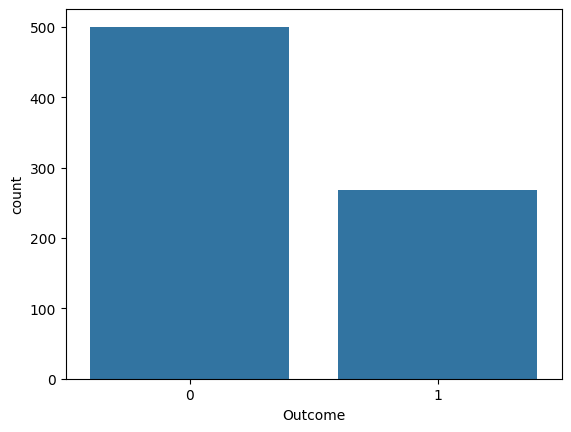

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# count plot on single categorical variable
sns.countplot(x ='Outcome', data =df)

# Show the plot
plt.show()

checking the percentage

In [ ]:
count_no_sub = len(df[df['Outcome']==0])
count_sub = len(df[df[('Outcome')]==1])

pct_of_no_sub = count_no_sub/(count_no_sub + count_sub)
print("percentage of no Diabetics is", pct_of_no_sub*100)
pct_of_sub = count_sub/(count_no_sub + count_sub)
print("percentage of Diabetics", pct_of_sub*100)


percentage of no Diabetics is 65.10416666666666
percentage of Diabetics 34.89583333333333


In [ ]:
#dealing with imbalanced dataset

#1. Oversampling: increase no of samples in minority class
#2. Undersampling: decrease no of samples in majority class
#3. Weights


#Oversampling

!pip install imblearn

from imblearn.over_sampling import SMOTE
x_resampled, y_resampled = SMOTE().fit_resample(x,y)

In [ ]:
#Split resampled dataset

#training-testing split

from sklearn.model_selection import train_test_split

x_train_bal,x_test_bal,y_train_bal,y_test_bal=train_test_split(x_resampled,y_resampled,test_size=0.2,random_state=10)

In [ ]:
#training ML Model
from sklearn.linear_model import LogisticRegression

bal_model = LogisticRegression()

#train
model.fit(x_train_bal,y_train_bal)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
#make prediction
y_pred_bal = model.predict(x_test_bal)

In [ ]:
#evaluate your ML model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print('Accuracy:', accuracy_score(y_test_bal,y_pred_bal))

print('Confusion:', confusion_matrix(y_test_bal,y_pred_bal))

print('Classification Report:', classification_report(y_test_bal,y_pred_bal))

Accuracy: 0.745
Confusion: [[72 21]
 [30 77]]
Classification Report:               precision    recall  f1-score   support

           0       0.71      0.77      0.74        93
           1       0.79      0.72      0.75       107

    accuracy                           0.74       200
   macro avg       0.75      0.75      0.74       200
weighted avg       0.75      0.74      0.75       200

